# Project  Hospital Management Analytics Dashboard

## Notebook: SQL Joins and Exploratory Data Analysis

This notebook prepares the first analytics-ready dataset for the Hospital Management Analytics Dashboard project.

### Objectives
- Load the raw hospital tables
- Inspect structure and data quality
- Join patient, appointment, and billing tables
- Perform basic exploratory analysis
- Create a merged dataset for dashboarding in Power BI

### Tables used
- `patients.csv`
- `appointments.csv`
- `billing.csv`

### Output of this notebook
- Initial insights into the dataset
- A cleaned and merged dashboard-ready file

In [1]:
# Import the main libraries used in this notebook
import pandas as pd
import matplotlib.pyplot as plt

# Optional display settings for easier inspection
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Load the raw datasets

In this section, we load the three CSV files that will be used for the first version of the dashboard.

At this stage, the goal is simply to make sure the files are readable and available in the expected project folders.

In [2]:
# Load raw datasets
patients = pd.read_csv("../data/raw/patients.csv")
appointments = pd.read_csv("../data/raw/appointments.csv")
billing = pd.read_csv("../data/raw/billing.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


## 2. Preview the tables

Before doing any joins, it is important to inspect the first few rows of each table.

This helps confirm:
- the files were loaded correctly
- the columns match expectations
- the join keys are present

In [3]:
print("Patients table")
patients.head()

Patients table


,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [4]:
print("Appointments table")
appointments.head()

Appointments table


,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [5]:
print("Billing table")
billing.head()

Billing table


,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.97,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.44,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.55,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.86,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.05,Credit Card,Pending


## 3. Inspect columns and data structure

Now we check the columns, data types, and overall shape of each table.

This step is important because in real-world datasets, column names and formats often need cleaning before analysis.

In [6]:
print("Patients shape:", patients.shape)
print("Appointments shape:", appointments.shape)
print("Billing shape:", billing.shape)

Patients shape: (50, 11)
Appointments shape: (200, 7)
Billing shape: (200, 7)


In [7]:
print("Patients columns:")
print(patients.columns.tolist())

print("\nAppointments columns:")
print(appointments.columns.tolist())

print("\nBilling columns:")
print(billing.columns.tolist())

Patients columns:
['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email']

Appointments columns:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status']

Billing columns:
['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount', 'payment_method', 'payment_status']


In [8]:
print("Patients info")
patients.info()

Patients info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          50 non-null     object
 1   first_name          50 non-null     object
 2   last_name           50 non-null     object
 3   gender              50 non-null     object
 4   date_of_birth       50 non-null     object
 5   contact_number      50 non-null     int64 
 6   address             50 non-null     object
 7   registration_date   50 non-null     object
 8   insurance_provider  50 non-null     object
 9   insurance_number    50 non-null     object
 10  email               50 non-null     object
dtypes: int64(1), object(10)
memory usage: 4.4+ KB


In [9]:
print("Appointments info")
appointments.info()

Appointments info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    200 non-null    object
 1   patient_id        200 non-null    object
 2   doctor_id         200 non-null    object
 3   appointment_date  200 non-null    object
 4   appointment_time  200 non-null    object
 5   reason_for_visit  200 non-null    object
 6   status            200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB


In [10]:
print("Billing info")
billing.info()

Billing info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bill_id         200 non-null    object 
 1   patient_id      200 non-null    object 
 2   treatment_id    200 non-null    object 
 3   bill_date       200 non-null    object 
 4   amount          200 non-null    float64
 5   payment_method  200 non-null    object 
 6   payment_status  200 non-null    object 
dtypes: float64(1), object(6)
memory usage: 11.1+ KB


## 4. Check missing values and duplicates

Before merging tables, we should identify missing values and duplicate rows.

This helps us understand:
- whether key columns are complete
- whether there are obvious data quality issues
- whether cleaning will be needed before dashboarding

In [12]:
print("Missing values in patients:")
print(patients.isnull().sum())

Missing values in patients:
patient_id            0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
dtype: int64


In [13]:
print("Missing values in appointments:")
print(appointments.isnull().sum())

Missing values in appointments:
appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
reason_for_visit    0
status              0
dtype: int64


In [14]:
print("Missing values in billing:")
print(billing.isnull().sum())

Missing values in billing:
bill_id           0
patient_id        0
treatment_id      0
bill_date         0
amount            0
payment_method    0
payment_status    0
dtype: int64


In [15]:
print("Duplicate rows in patients:", patients.duplicated().sum())
print("Duplicate rows in appointments:", appointments.duplicated().sum())
print("Duplicate rows in billing:", billing.duplicated().sum())

Duplicate rows in patients: 0
Duplicate rows in appointments: 0
Duplicate rows in billing: 0


## 5. Standardize column names

To make analysis easier, we convert all column names to lowercase and replace spaces with underscores.

This makes coding cleaner and avoids issues later when selecting columns.

In [16]:
# Standardize column names
patients.columns = patients.columns.str.strip().str.lower().str.replace(" ", "_")
appointments.columns = appointments.columns.str.strip().str.lower().str.replace(" ", "_")
billing.columns = billing.columns.str.strip().str.lower().str.replace(" ", "_")

print("Column names standardized.")

Column names standardized.


In [17]:
print("Patients columns:")
print(patients.columns.tolist())

print("\nAppointments columns:")
print(appointments.columns.tolist())

print("\nBilling columns:")
print(billing.columns.tolist())

Patients columns:
['patient_id', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email']

Appointments columns:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status']

Billing columns:
['bill_id', 'patient_id', 'treatment_id', 'bill_date', 'amount', 'payment_method', 'payment_status']


## 6. Inspect join keys

The main join key across these tables is `patient_id`.

Before joining, we should make sure the key exists and has a compatible format in each table.

In [18]:
print("Sample patient_id values from patients:")
print(patients["patient_id"].head())

print("\nSample patient_id values from appointments:")
print(appointments["patient_id"].head())

print("\nSample patient_id values from billing:")
print(billing["patient_id"].head())

Sample patient_id values from patients:
0    P001
1    P002
2    P003
3    P004
4    P005
Name: patient_id, dtype: object

Sample patient_id values from appointments:
0    P034
1    P032
2    P048
3    P025
4    P040
Name: patient_id, dtype: object

Sample patient_id values from billing:
0    P034
1    P032
2    P048
3    P025
4    P040
Name: patient_id, dtype: object


In [19]:
print("patient_id dtype in patients:", patients["patient_id"].dtype)
print("patient_id dtype in appointments:", appointments["patient_id"].dtype)
print("patient_id dtype in billing:", billing["patient_id"].dtype)

patient_id dtype in patients: object
patient_id dtype in appointments: object
patient_id dtype in billing: object


## 7. Merge the tables

Now we create the first dashboard-ready dataset.

### Merge logic
- Start from `appointments`
- Join `patients` on `patient_id`
- Join `billing` on `patient_id`

This gives us one table containing:
- patient details
- appointment details
- billing information

This merged dataset will later be used in Power BI.

In [20]:
merged_df = appointments.merge(
    patients,
    on="patient_id",
    how="left"
)

merged_df = merged_df.merge(
    billing,
    on="patient_id",
    how="left"
)

print("Merged dataset created successfully.")

Merged dataset created successfully.


In [21]:
merged_df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email,bill_id,treatment_id,bill_date,amount,payment_method,payment_status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com,B001,T001,2023-08-09,3941.97,Insurance,Pending
1,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com,B043,T043,2023-03-29,3207.25,Insurance,Failed
2,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,1950-01-26,8374657733,321 Maple Dr,2023-06-18,WellnessCorp,INS653880,alex.smith@mail.com,B093,T093,2023-04-09,1955.17,Credit Card,Failed
3,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com,B002,T002,2023-06-09,4158.44,Insurance,Paid
4,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,1981-01-08,8102183595,123 Elm St,2021-10-02,MedCare Plus,INS335362,alex.moore@mail.com,B047,T047,2023-05-02,1454.20,Insurance,Failed


In [22]:
print("Merged dataset shape:", merged_df.shape)
print("Merged dataset columns:")
print(merged_df.columns.tolist())

Merged dataset shape: (1002, 23)
Merged dataset columns:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_time', 'reason_for_visit', 'status', 'first_name', 'last_name', 'gender', 'date_of_birth', 'contact_number', 'address', 'registration_date', 'insurance_provider', 'insurance_number', 'email', 'bill_id', 'treatment_id', 'bill_date', 'amount', 'payment_method', 'payment_status']


## 8. Initial quality check on the merged dataset

Now that the tables are merged, we inspect the result for:
- missing values
- duplicates
- general structure

This helps confirm whether the merged file is usable for dashboarding.

In [23]:
print("Missing values in merged dataset:")
print(merged_df.isnull().sum())

Missing values in merged dataset:
appointment_id        0
patient_id            0
doctor_id             0
appointment_date      0
appointment_time      0
reason_for_visit      0
status                0
first_name            0
last_name             0
gender                0
date_of_birth         0
contact_number        0
address               0
registration_date     0
insurance_provider    0
insurance_number      0
email                 0
bill_id               0
treatment_id          0
bill_date             0
amount                0
payment_method        0
payment_status        0
dtype: int64


In [24]:
print("Duplicate rows in merged dataset:", merged_df.duplicated().sum())

Duplicate rows in merged dataset: 0


## 9. Quick KPI exploration

In this section, we calculate a few basic metrics that may later become dashboard cards or visuals.

These are only initial exploratory checks.

In [25]:
# Total registered patients
total_patients = merged_df["patient_id"].nunique()
print("Total registered patients:", total_patients)

Total registered patients: 48


In [26]:
# Total appointments
total_appointments = merged_df["appointment_id"].nunique()
print("Total appointments:", total_appointments)

Total appointments: 200


In [27]:
# Total revenue
total_revenue = merged_df["amount"].sum()
print("Total revenue:", total_revenue)

Total revenue: 2748290.16


In [28]:
# Appointment status distribution
print("Appointment status distribution:")
print(merged_df["status"].value_counts())

Appointment status distribution:
status
No-show      283
Scheduled    259
Cancelled    251
Completed    209
Name: count, dtype: int64


In [29]:
# Payment status distribution
print("Payment status distribution:")
print(merged_df["payment_status"].value_counts())

Payment status distribution:
payment_status
Paid       351
Failed     333
Pending    318
Name: count, dtype: int64


## 10. Basic visual exploration

We now create a few simple charts to understand patterns in appointments and billing.

These are not final dashboard visuals yet.  
They are exploratory charts to help us understand the data.

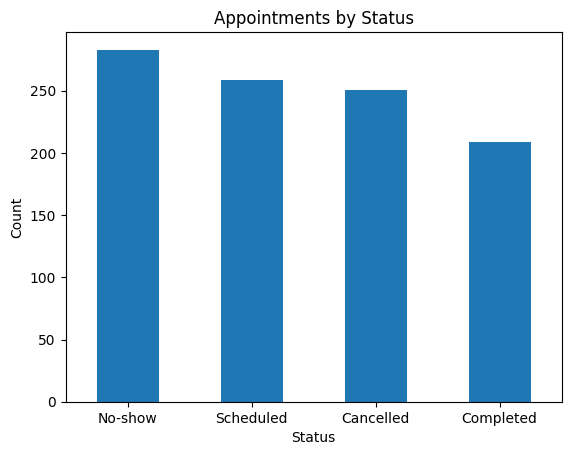

In [30]:
# Appointments by status
merged_df["status"].value_counts().plot(kind="bar")
plt.title("Appointments by Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

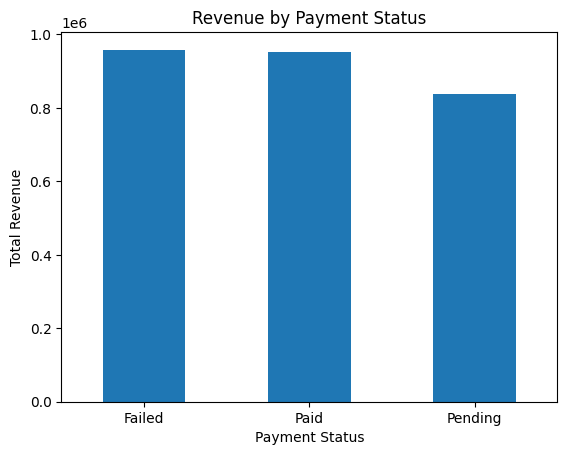

In [31]:
# Revenue by payment status
merged_df.groupby("payment_status")["amount"].sum().plot(kind="bar")
plt.title("Revenue by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

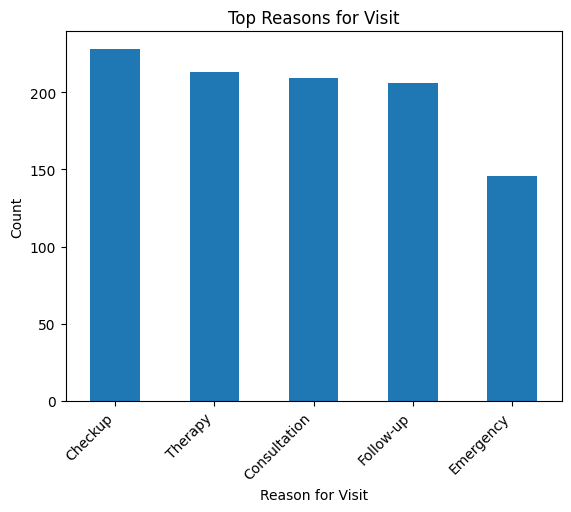

In [32]:
# Appointments by reason for visit
merged_df["reason_for_visit"].value_counts().head(10).plot(kind="bar")
plt.title("Top Reasons for Visit")
plt.xlabel("Reason for Visit")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

## 11. Save the merged dataset

The final step in this notebook is to export the merged table to the `processed` folder.

This file will be used as the main input for Power BI in the next stage of the project.

In [33]:
merged_df.to_csv("../data/processed/merged_dashboard_dataset.csv", index=False)
print("Merged dashboard dataset saved successfully.")

Merged dashboard dataset saved successfully.


## 12. Summary of progress

At this stage, the following has been completed:

- Loaded three raw hospital tables
- Inspected columns and data quality
- Standardized column names
- Merged the tables using `patient_id`
- Calculated initial KPIs
- Created basic exploratory charts
- Exported a dashboard-ready dataset

### Next step
The next stage will focus on:
- cleaning any remaining issues
- improving KPI definitions
- building the Power BI dashboard